In [93]:
!pip install gensim

In [94]:
import math
import string
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import word_tokenize, pos_tag

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [95]:
def get_from_file(file_df):
  df=pd.read_csv(file_df)
  df.head()

  # Undersampling because of the predominance of neutral sentiment data
  if file_df == "/content/drive/MyDrive/IR_NLP_2025_Shared/Data/MELD DataSet/train_sent_emo.csv":
    min_count = df['Sentiment'].value_counts().min()
    df_balanced = df.groupby('Sentiment').sample(n=min_count, random_state=42).reset_index(drop=True)
    x=df_balanced['Utterance'].tolist()
    y=df_balanced['Sentiment'].tolist()

    return x,y

  x=df['Utterance'].tolist()
  y=df['Sentiment'].tolist()
  return x,y

In [96]:
file_train="/content/drive/MyDrive/IR_NLP_2025_Shared/Data/MELD DataSet/train_sent_emo.csv"

utterance,sentiment=get_from_file(file_train)

print(utterance)
print(sentiment)

["I don't believe they're brother and sister.", 'Oh, you so would! Oh, you should get that anyway.  Like for clubbing.', 'Okay, listen this really hurts. Let\x92s go.', 'And yet, we\x92re still poking him.', 'What are you crazy?!', "Okay, this isn't working. I'm still awake and now I have to pee.", 'Hey, no way! Come on, this is you guys, call her and work it out.', "When I first moved to the city, I went out a couple of times with this girl, really hot, great kisser, but she had the biggest Adam's apple.", 'No I mean\x97No not you, not you, you\x97you', 'Oh my God! Oh my God!', 'Ow!! Ow!!!', "Oh he's like a...", 'Me?', "It's just that we bought a hibachi together, and then he ran off and got married, and things got pretty ugly.", 'Crap!!', 'What are you talking about? Bitch.', 'What?!', 'It-it\x97The point is my natural charisma has made him fail his midterm.', 'Thanks.', 'Come on more!', 'You\x92re kidding right?', 'Okay, I don\x92t know what to do anymore.', 'No-no-no! We gotta go! 

In [97]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default

def tokenize(sentences):
    negations = {
        "not", "no", "never", "none", "nobody", "nothing", "neither", "nowhere",
        "hardly", "scarcely", "barely",
        "doesn't", "isn't", "wasn't", "shouldn't", "wouldn't", "couldn't",
        "won't", "can't", "don't", "didn't", "aren't", "haven't", "hasn't",
        "mustn't", "mightn't", "needn't", "shan't", "ain't","n't"
    }
    punctuation = set(string.punctuation)

    tokenized_list = []
    lemmatized_sentences = []

    for sent in sentences:
        sent = sent.replace('\x92', "'")
        sent = sent.replace('\x97', '-')

        tokens_nl = word_tokenize(sent)
        tagged = pos_tag(tokens_nl)
        tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(pos)) if word.isalpha() else word for word, pos in tagged]  #mantaining punctuation: it improves performance in positive sentiment recogntion
        #adding not_ prefix to all the words that come after a negation until a punctuation symbol is encountered
        new_tokens = []
        negated = False
        for token in tokens:
            lower_token = token.lower()
            if negated:
                if lower_token in punctuation:
                    negated = False
                    new_tokens.append(lower_token)
                else:
                    new_tokens.append("not_" + lower_token)
            else:
                new_tokens.append(lower_token)
                if lower_token in negations:
                    negated = True
        tokenized_list.append(new_tokens)

    return tokenized_list


tokenized_utterance=tokenize(utterance)

print(tokenized_utterance)
print(sentiment)

[['i', 'do', "n't", 'not_believe', 'not_they', "not_'re", 'not_brother', 'not_and', 'not_sister', '.'], ['oh', ',', 'you', 'so', 'would', '!', 'oh', ',', 'you', 'should', 'get', 'that', 'anyway', '.', 'like', 'for', 'clubbing', '.'], ['okay', ',', 'listen', 'this', 'really', 'hurt', '.', 'let', "'s", 'go', '.'], ['and', 'yet', ',', 'we', "'re", 'still', 'poke', 'him', '.'], ['what', 'be', 'you', 'crazy', '?', '!'], ['okay', ',', 'this', 'be', "n't", 'not_work', '.', 'i', "'m", 'still', 'awake', 'and', 'now', 'i', 'have', 'to', 'pee', '.'], ['hey', ',', 'no', 'not_way', '!', 'come', 'on', ',', 'this', 'be', 'you', 'guy', ',', 'call', 'her', 'and', 'work', 'it', 'out', '.'], ['when', 'i', 'first', 'move', 'to', 'the', 'city', ',', 'i', 'go', 'out', 'a', 'couple', 'of', 'time', 'with', 'this', 'girl', ',', 'really', 'hot', ',', 'great', 'kisser', ',', 'but', 'she', 'have', 'the', 'big', 'adam', "'s", 'apple', '.'], ['no', 'not_i', 'not_mean-no', 'not_not', 'not_you', ',', 'not', 'not_you'

In [98]:
from gensim.models import Word2Vec
from gensim.models import FastText

# Train the Word2Vec model
# window=2 means the context window size is 2 words on each side

w2v_model = Word2Vec(tokenized_utterance, vector_size=300, window=5, min_count=1, workers=4)

#print(w2v_model.wv['this'])

#print(w2v_model.wv.most_similar('cash'))


In [99]:
import numpy as np

def get_sentence_embedding(sentence, model):
    vectors = [w2v_model.wv[word] for word in sentence if word in w2v_model.wv]  #forming utterances with words in the vocabulary
    if vectors:
        return np.mean(vectors, axis=0) # each component of the vector is mediated--> embedding of the utterance
    else:
        return np.zeros(model.vector_size)       #if a sentence is full of word not in vocabulary then fill his vector of zeros

emb_utterance = np.array([get_sentence_embedding(t, w2v_model) for t in tokenized_utterance])

print(len(emb_utterance))
print(len(sentiment))

7002
7002


In [100]:
file_dev="/content/drive/MyDrive/IR_NLP_2025_Shared/Data/MELD DataSet/dev_sent_emo.csv"

utterance_dev,sentiment_dev=get_from_file(file_dev)

tokenized_utterance_dev=tokenize(utterance_dev)
emb_utterance_dev = np.array([get_sentence_embedding(t, w2v_model) for t in tokenized_utterance_dev])

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


clf = LogisticRegression(
    C=1e4,
    max_iter=5000
)

clf.fit(emb_utterance, sentiment)


sentiment_pred_dev = clf.predict(emb_utterance_dev)
print("dev set")
print(classification_report(sentiment_dev, sentiment_pred_dev, target_names=["negative", "neutral", "positive"]))


dev set
              precision    recall  f1-score   support

    negative       0.55      0.38      0.45       406
     neutral       0.62      0.75      0.68       470
    positive       0.47      0.53      0.50       233

    accuracy                           0.57      1109
   macro avg       0.55      0.55      0.54      1109
weighted avg       0.56      0.57      0.56      1109



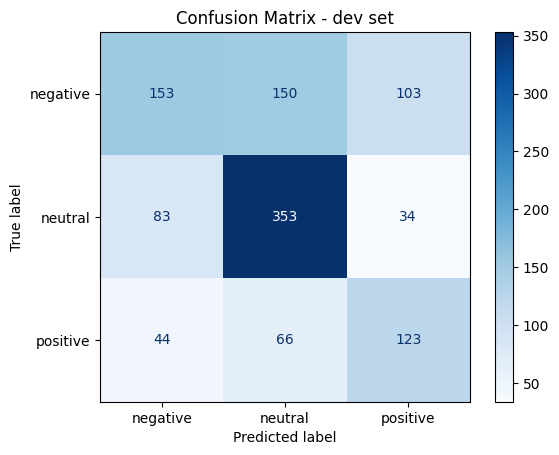

In [102]:
import matplotlib.pyplot as plt

cm = confusion_matrix(sentiment_dev, sentiment_pred_dev)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "neutral", "positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - dev set")
plt.show()

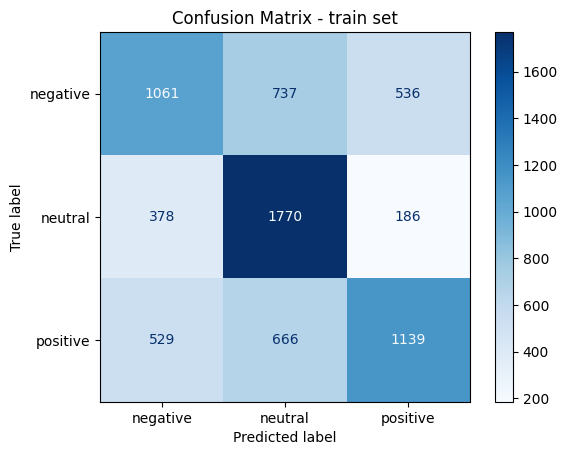

In [103]:
import matplotlib.pyplot as plt
sentiment_pred_train = clf.predict(emb_utterance)
cm = confusion_matrix(sentiment, sentiment_pred_train)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "neutral", "positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - train set")
plt.show()

TEST SET

              precision    recall  f1-score   support

    negative       0.55      0.42      0.48       833
     neutral       0.69      0.77      0.73      1256
    positive       0.47      0.52      0.49       521

    accuracy                           0.61      2610
   macro avg       0.57      0.57      0.57      2610
weighted avg       0.60      0.61      0.60      2610



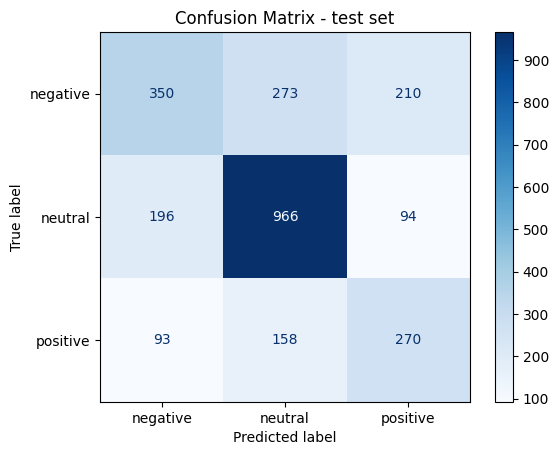

In [104]:
file_test="/content/drive/MyDrive/test_sent_emo.csv"

utterance_test,sentiment_test=get_from_file(file_test)

tokenized_utterance_test=tokenize(utterance_test)
emb_utterance_test = np.array([get_sentence_embedding(t, w2v_model) for t in tokenized_utterance_test])

sentiment_pred_test = clf.predict(emb_utterance_test)
print(classification_report(sentiment_test, sentiment_pred_test, target_names=["negative", "neutral", "positive"]))

cm = confusion_matrix(sentiment_test, sentiment_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negative", "neutral", "positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - test set")
plt.show()

In [105]:
from keras.preprocessing.sequence import pad_sequences

MAX_LEN = 10  # length of sequence given to rnn

def sentence_to_sequence(sentence, model, max_len=MAX_LEN):
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) == 0:
        return np.zeros((max_len, model.vector_size))

    sequence = pad_sequences([vectors], maxlen=max_len, dtype='float32', padding='post', truncating='post')[0]
    return sequence

X_train_seq = np.array([sentence_to_sequence(t, w2v_model) for t in tokenized_utterance])
X_val_seq = np.array([sentence_to_sequence(t, w2v_model) for t in tokenized_utterance_dev])


from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(sentiment)
y_val = label_encoder.transform(sentiment_dev)

num_classes = len(label_encoder.classes_)


from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Masking, SimpleRNN

model = Sequential()

model.add(Masking(mask_value=0., input_shape=(MAX_LEN, 300)))
model.add(SimpleRNN(64, return_sequences=True))
model.add(SimpleRNN(64, return_sequences=True))
model.add(SimpleRNN(32))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))
'''
#MLP
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(sentiment)
y_val = label_encoder.transform(sentiment_dev)
y_test = label_encoder.transform(sentiment_test)


model = Sequential()
model.add(Dense(128, input_shape=(300,), activation='relu'))
model.add(Dense(64, input_shape=(300,), activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))
'''
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_5 (Masking)             │ (None, 10, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ (None, 10, 64)         │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_16 (SimpleRNN)       │ (None, 10, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_17 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,819 (136.01 KB)

 Trainable params: 34,819 (136.01 KB)

 Non-trainable params: 0 (0.00 B)

In [106]:
from keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    filepath='best_model.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

model.fit(X_train_seq, y_train, epochs=10, batch_size=64, validation_data=(X_val_seq, y_val), callbacks=[checkpoint])


Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3514 - loss: 1.1851
Epoch 1: val_accuracy improved from -inf to 0.25699, saving model to best_model.weights.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.3513 - loss: 1.1850 - val_accuracy: 0.2570 - val_loss: 1.1305
Epoch 2/10
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3452 - loss: 1.1362
Epoch 2: val_accuracy improved from 0.25699 to 0.43012, saving model to best_model.weights.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3455 - loss: 1.1361 - val_accuracy: 0.4301 - val_loss: 1.0658
Epoch 3/10
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3560 - loss: 1.1127
Epoch 3: val_accuracy did not improve from 0.43012
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.3564 - loss: 1.1126 - val_accuracy: 0.3986 - val_loss: 1.0893
Epoch 4/10
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3988 - loss: 1.0921
Epoch 4: val_accuracy improved from 0.43012 to 0.48422, saving

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

    negative       0.43      0.51      0.47       406
     neutral       0.60      0.60      0.60       470
    positive       0.45      0.31      0.37       233

    accuracy                           0.50      1109
   macro avg       0.49      0.47      0.48      1109
weighted avg       0.51      0.50      0.50      1109



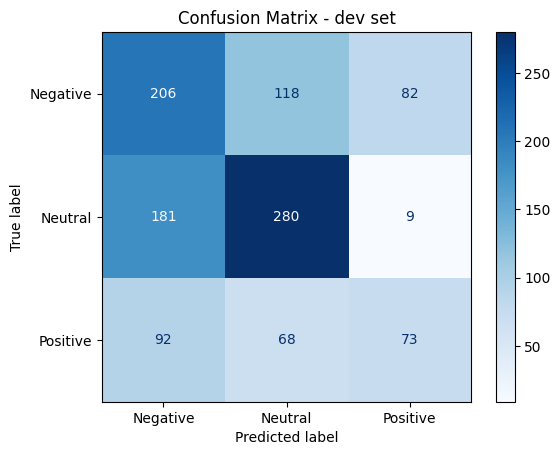

In [107]:
model.load_weights('best_model.weights.h5')

from sklearn.metrics import classification_report

y_pred = model.predict(X_val_seq)

y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_val, y_pred_classes, target_names=label_encoder.classes_))

cm = confusion_matrix(y_val, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative","Neutral","Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - dev set")
plt.show()


82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

    negative       0.40      0.56      0.47       833
     neutral       0.65      0.55      0.60      1256
    positive       0.47      0.34      0.39       521

    accuracy                           0.51      2610
   macro avg       0.51      0.48      0.49      2610
weighted avg       0.53      0.51      0.51      2610



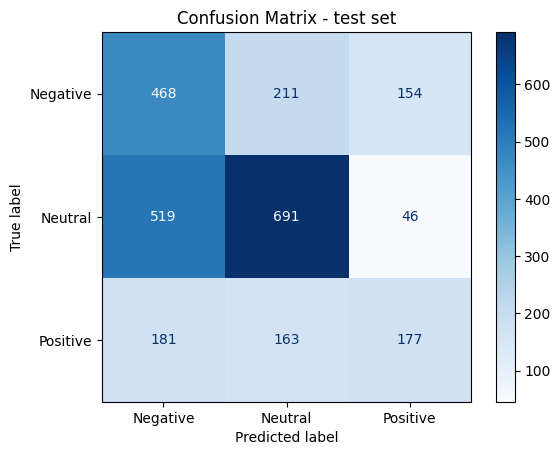

In [108]:
y_test = label_encoder.transform(sentiment_test)
X_test_seq = np.array([sentence_to_sequence(t, w2v_model) for t in tokenized_utterance_test])

y_pred = model.predict(X_test_seq)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative","Neutral","Positive"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - test set")
plt.show()